# Harry Neal - Hyrox Performance Analytics

*Hyrox Performance Analytics is a data science project built on ~21,000 self-scraped race results from the official Hyrox results site. It asks three connected questions: can we predict an athlete's finish time mid-race, how much does the venue itself change finish times, and do athletes fall into distinct pacing strategies?*

## Notebook 2 of 4 - In-Race Finish Time Prediction

### Introduction

This notebook builds the project's flagship model. The question it answers is the one every
racer (and spectator) actually asks mid-race:

> *"Given your splits so far — when will you finish?"*

A Hyrox race is a fixed sequence of 16 timed segments (8 × 1 km runs alternating with
8 workout stations), so every athlete passes the same 16 checkpoints in the same order. We
train **one model per checkpoint**: the "after run 3" model simulates a prediction made at the
moment the athlete steps off the run-3 mat, the "after wall balls" model a prediction with the
whole race bar the final transition known. The inputs come from the clean modeling table built
in [notebook 1](Harry_Neal_Hyrox_1_data_acquisition_cleaning_eda.ipynb): 20,200 finishers across
24 events (seasons 5–6, OPEN division), with gender and age group recovered via the label
scrape.

Three methodological commitments shape everything below:

1. **Leakage discipline.** Every completed race in the table contains all 16 splits, so nothing
   *physically* prevents the "after run 3" model from seeing run 8. A feature is admissible at
   checkpoint *k* only if it is computable from segments 1..*k* plus pre-race covariates.
   Leakage here wouldn't make the model fail — it would make it succeed fraudulently
   (total time is roughly the sum of the splits), which is worse.
2. **Grouped validation.** Athletes nest within events: same course, same venue conditions, same
   field. Random row splits would put London athletes in both train and test and flatter the
   model. Every result below is **leave-event-out**: the test event's athletes, venue, and
   conditions are entirely unseen.
3. **Calibrated uncertainty.** A point estimate without an error bar is close to useless
   mid-race. We predict 90% intervals and then *check* that they cover 90% of unseen athletes —
   and when the raw intervals fall short under event shift, we repair them with conformal
   calibration rather than report nominal coverage we don't have.

### Method

#### What is knowable at checkpoint *k*

The feature builder ([`src/processing/checkpoint_features.py`](../src/processing/checkpoint_features.py))
constructs, for each checkpoint, only the admissible information:

| Feature family | Examples | Available |
|---|---|---|
| Individual splits so far | `run_1` … segment *k* | from checkpoint 1 |
| Cumulative work time | `cum_time`, `cum_run_time`, `cum_station_time` | from checkpoint 1 |
| Run pacing so far | mean, last, slope, last-vs-first, std | slope/std need ≥ 2 runs |
| Station profile so far | mean, last, station share of work time | from checkpoint 2 |
| Pre-race covariates | gender, age group | always |

Two things are deliberately absent. The whole-race features engineered for post-race analysis
(fatigue slope across all 8 runs, finish strength, positive/negative split) are illegal at every
checkpoint before the finish — they return in notebook 4, where the race is over and using all
of it is the point. And **transition (Roxzone) time so far is unobservable**: the results site
publishes roxzone only as a race total, so mid-race we know the work segments completed but not
the transition time consumed between them. Features therefore use work-segment sums, and the
mapping to the finish clock (which includes roxzone) is left to the models.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

from src.processing.checkpoint_features import (
    CHECKPOINTS, build_checkpoint_features, prepare_modeling_frame, checkpoint_label)
from src.models.inrace import ProportionalBaseline

clean = pd.read_csv("../data/processed/hyrox_clean.csv")
df = prepare_modeling_frame(clean)
print(f"modeling frame: {len(df):,} athletes, {df.event_id.nunique()} events "
      f"({clean.is_modeling_row.sum() - len(df)} rows dropped for missing gender)")

# the admissible feature set grows with the race: 7 features after run 1, 29 by the final station
for k in [1, 4, 16]:
    feats = build_checkpoint_features(df, k)
    print(f"checkpoint {k:>2} ({checkpoint_label(k)}): {feats.shape[1]} features")
build_checkpoint_features(df, 4).head(3)

modeling frame: 20,200 athletes, 24 events (3 rows dropped for missing gender)
checkpoint  1 (after run 1): 7 features
checkpoint  4 (after station 2): 17 features
checkpoint 16 (after station 8): 29 features


,run_1,station_1,run_2,station_2,cum_time,cum_run_time,run_mean_so_far,run_last,run_slope_so_far,run_last_vs_first,run_std_so_far,cum_station_time,station_mean_so_far,station_last,station_share_so_far,gender,age_group
0,236.0,232.0,247.0,136.0,851.0,483.0,241.5,247.0,11.0,11.0,5.5,368.0,184.0,136.0,0.432432,M,30-34
1,252.0,275.0,264.0,173.0,964.0,516.0,258.0,264.0,12.0,12.0,6.0,448.0,224.0,173.0,0.464730,W,35-39
2,244.0,242.0,238.0,149.0,873.0,482.0,241.0,238.0,-6.0,-6.0,3.0,391.0,195.5,149.0,0.447881,M,30-34


#### The baseline: proportional extrapolation

Any learned model has to beat the prediction a knowledgeable spectator would make with a
calculator. At checkpoint *k*, take the work time so far and divide by the **median fraction of
the finish time** that work-through-*k* represents among same-gender training athletes:

$$\hat{t}_{\text{finish}} = \frac{\text{cumulative work time}_k}{\text{median}_g\left(\text{cumulative}_k / \text{finish}\right)}$$

Because the denominator is calibrated against the *finish* clock, the unobserved roxzone time is
absorbed automatically. This baseline is brutally strong late in the race — by the final station
the cumulative split sum is ~93% of the finish time and extrapolation is nearly arithmetic.

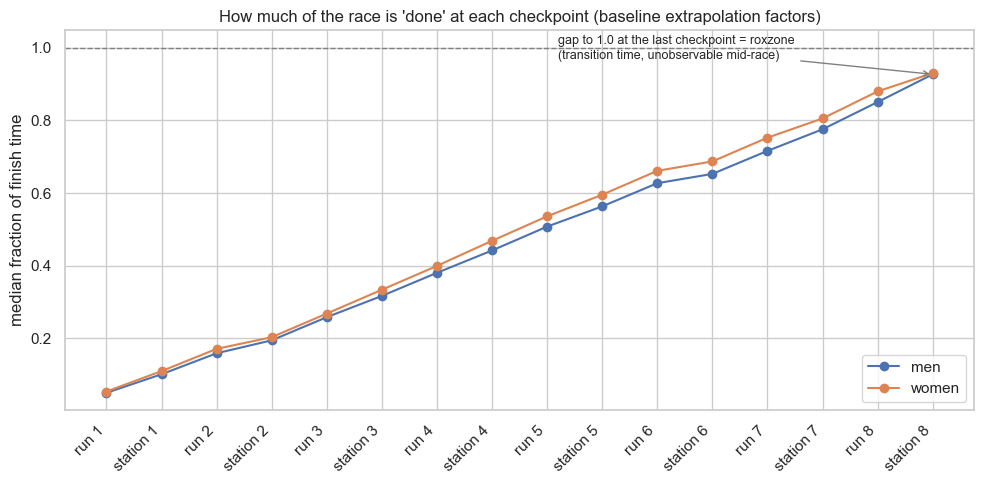

In [2]:
baseline = ProportionalBaseline().fit(df)
frac = baseline.fractions_

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(1, 17)
for g, color, label in [("M", "#4C72B0", "men"), ("W", "#DD8452", "women")]:
    ax.plot(x, frac.loc[g, CHECKPOINTS], "o-", color=color, label=label)
ax.axhline(1.0, color="grey", ls="--", lw=1)
ax.annotate("gap to 1.0 at the last checkpoint = roxzone\n(transition time, unobservable mid-race)",
            xy=(16, frac.loc["M", "station_8"]), xytext=(9.2, 0.97), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="grey"))
ax.set_xticks(x)
ax.set_xticklabels([c.replace("_", " ") for c in CHECKPOINTS], rotation=45, ha="right")
ax.set_ylabel("median fraction of finish time")
ax.set_title("How much of the race is 'done' at each checkpoint (baseline extrapolation factors)")
ax.legend()
plt.tight_layout()

#### Models: gradient-boosted quantile regression

For each checkpoint we fit three LightGBM models with the quantile objective — the 5th, 50th and
95th percentiles ([`src/models/inrace.py`](../src/models/inrace.py)). The median model is the
point prediction (it directly optimises absolute error); the outer pair forms a nominal 90%
prediction interval. One model family gives us both the point forecast and the uncertainty, and
gradient boosting handles the mixed numeric/categorical features and their interactions without
manual specification.

#### Validation: leave-event-out, with conformal repair

The experiment ([`scripts/run_phase2_models.py`](../scripts/run_phase2_models.py)) runs 24 folds —
each holds out one entire event. Within each fold's 23 training events, **4 whole events** are
further held out as a *conformal calibration set* for CQR (conformalized quantile regression):
the raw (q05, q95) interval is widened by the smallest constant that achieves 90% coverage on
the calibration events. Calibrating on held-out *events* rather than held-out *rows* matters —
the correction then reflects the event-to-event shift the test fold actually faces, not the
easier within-event variation.

The full run is 24 folds × 16 checkpoints × 3 quantile fits = **1,152 model fits (~8 minutes)**;
this notebook loads its saved predictions rather than re-running it
(`.venv/bin/python3 scripts/run_phase2_models.py` to reproduce).

In [3]:
preds = pd.read_csv("../data/processed/phase2/predictions.csv.gz")
by_cp = pd.read_csv("../data/processed/phase2/metrics_by_checkpoint.csv")
by_fold = pd.read_csv("../data/processed/phase2/metrics_by_fold.csv")
print(f"{len(preds):,} predictions ({preds.row.nunique():,} athletes x {preds.checkpoint.nunique()} checkpoints), "
      f"all from models that never saw the athlete's event")
by_cp.round(2).head(8)

323,200 predictions (20,200 athletes x 16 checkpoints), all from models that never saw the athlete's event


,checkpoint,segment,n,mae_baseline,mae_model,mape_model,coverage_raw,coverage_cqr,width_raw,width_cqr,improvement_pct
0,1,run_1,20200.0,834.81,662.30,9.80,0.86,0.88,2452.13,2566.52,20.66
1,2,station_1,20200.0,574.13,538.79,8.04,0.85,0.88,1896.51,2065.30,6.15
2,3,run_2,20200.0,445.88,357.48,4.88,0.84,0.89,1155.12,1316.48,19.82
3,4,station_2,20200.0,391.88,326.54,4.41,0.84,0.90,1036.92,1210.77,16.67
4,5,run_3,20200.0,342.29,287.48,3.95,0.83,0.89,925.28,1099.79,16.01
5,6,station_3,20200.0,304.98,266.11,3.59,0.83,0.89,843.60,1016.11,12.75
6,7,run_4,20200.0,276.44,247.29,3.36,0.82,0.89,787.76,968.93,10.55
7,8,station_4,20200.0,197.25,185.09,2.46,0.82,0.89,578.65,707.21,6.16


### Results

#### Point accuracy: where the model earns its keep

After a single run (~5% of the race), the model predicts the finish time of a ~95-minute race
with a **median-absolute-style error of ~11 minutes**, against ~14 for the baseline — a **21%
improvement exactly where prediction is hardest and most valuable**. The advantage persists
through the whole midrace (typically 6–17%), and the absolute error falls to ~2.5 minutes by the
final stations.

The one place the model loses is the very last checkpoint: after wall balls the only unknown is
the athlete's total transition time, and proportional arithmetic beats the learned model by ~5%.
That is the honest shape of this problem — late in the race there is almost nothing left to
learn, and a leave-event-out evaluation is exactly what surfaces it.

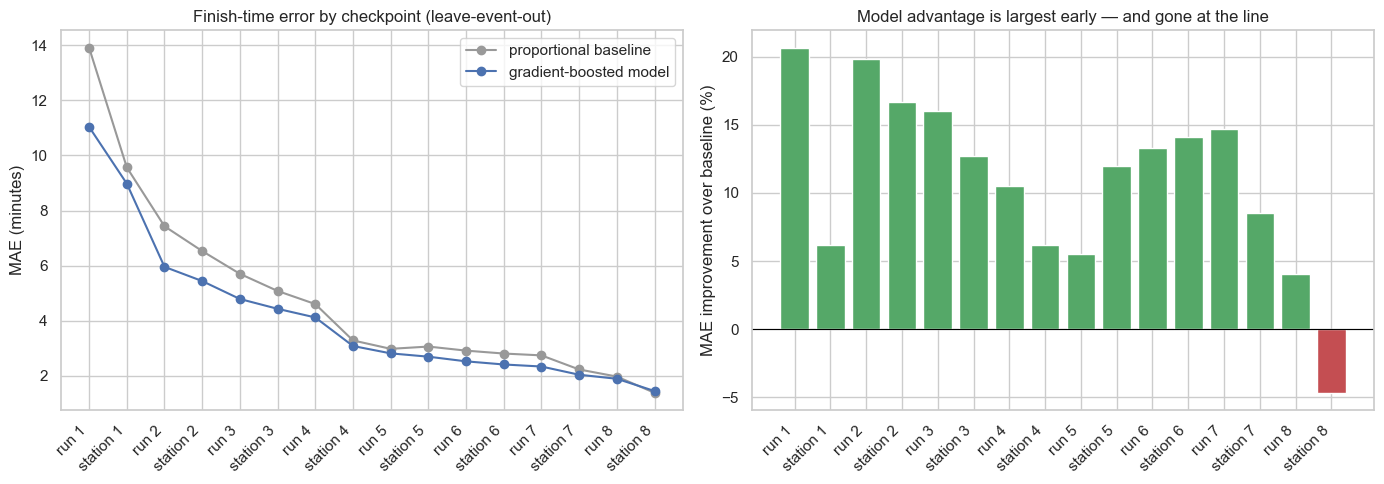

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = by_cp.checkpoint

ax = axes[0]
ax.plot(x, by_cp.mae_baseline / 60, "o-", color="#999999", label="proportional baseline")
ax.plot(x, by_cp.mae_model / 60, "o-", color="#4C72B0", label="gradient-boosted model")
ax.set_xticks(x)
ax.set_xticklabels([s.replace("_", " ") for s in by_cp.segment], rotation=45, ha="right")
ax.set_ylabel("MAE (minutes)")
ax.set_title("Finish-time error by checkpoint (leave-event-out)")
ax.legend()

ax = axes[1]
colors = ["#C44E52" if v < 0 else "#55A868" for v in by_cp.improvement_pct]
ax.bar(x, by_cp.improvement_pct, color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([s.replace("_", " ") for s in by_cp.segment], rotation=45, ha="right")
ax.set_ylabel("MAE improvement over baseline (%)")
ax.set_title("Model advantage is largest early — and gone at the line")
plt.tight_layout()

#### Uncertainty you can act on — after checking it

The raw quantile models, trained on other events, **undercover on held-out events at every
checkpoint**: empirical coverage of the nominal 90% interval runs 0.79–0.86. This is the grouped
structure biting again — quantiles calibrated on the training events' conditions are too narrow
for an unseen venue. The CQR correction (calibrated on held-out *events*) repairs this to
0.88–0.90 across the board, at the cost of slightly wider intervals.

The repaired intervals tell the story of information arriving as the race unfolds: the 90%
interval is **~43 minutes wide after run 1 and ~6 minutes wide after wall balls**.

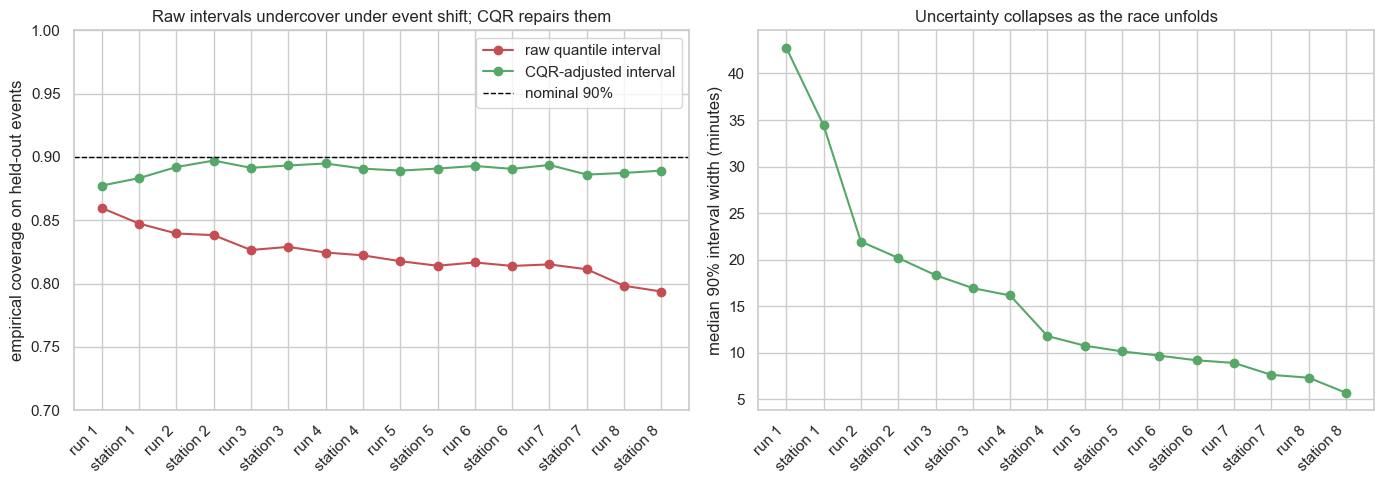

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = by_cp.checkpoint

ax = axes[0]
ax.plot(x, by_cp.coverage_raw, "o-", color="#C44E52", label="raw quantile interval")
ax.plot(x, by_cp.coverage_cqr, "o-", color="#55A868", label="CQR-adjusted interval")
ax.axhline(0.9, color="black", ls="--", lw=1, label="nominal 90%")
ax.set_xticks(x)
ax.set_xticklabels([s.replace("_", " ") for s in by_cp.segment], rotation=45, ha="right")
ax.set_ylabel("empirical coverage on held-out events")
ax.set_ylim(0.7, 1.0)
ax.set_title("Raw intervals undercover under event shift; CQR repairs them")
ax.legend()

ax = axes[1]
ax.plot(x, by_cp.width_cqr / 60, "o-", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels([s.replace("_", " ") for s in by_cp.segment], rotation=45, ha="right")
ax.set_ylabel("median 90% interval width (minutes)")
ax.set_title("Uncertainty collapses as the race unfolds")
plt.tight_layout()

#### Robustness across events

Pooled metrics can hide a model that aces big events and fails small ones. Splitting the same
predictions by held-out event: the checkpoint-by-checkpoint error profile holds for every one of
the 24 events, with no catastrophic outlier fold — the spread between the easiest and hardest
events narrows as the race progresses, exactly as the within-race information starts to dominate
whatever is venue-specific.

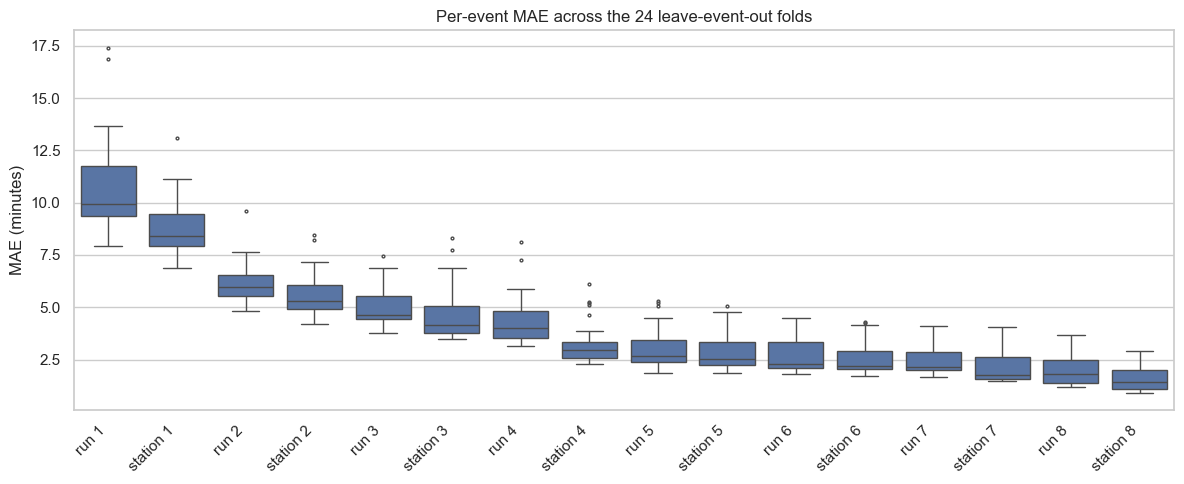

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=by_fold.assign(mae_min=by_fold.mae_model / 60),
            x="checkpoint", y="mae_min", color="#4C72B0", ax=ax, fliersize=2)
ax.set_xticks(range(len(by_cp)))
ax.set_xticklabels([s.replace("_", " ") for s in by_cp.segment], rotation=45, ha="right")
ax.set_xlabel("")
ax.set_ylabel("MAE (minutes)")
ax.set_title("Per-event MAE across the 24 leave-event-out folds")
plt.tight_layout()

#### What drives an early-race prediction

Fitting the median model at the fourth checkpoint (after the sled push — two runs and two
stations in, ~20% of the race) on the full dataset and reading LightGBM's gain importances: the
**cumulative and run-pace features dominate**, with the early stations adding texture. Gender —
so painful to recover in notebook 1 — carries real signal this early, before pace has fully
revealed the athlete.

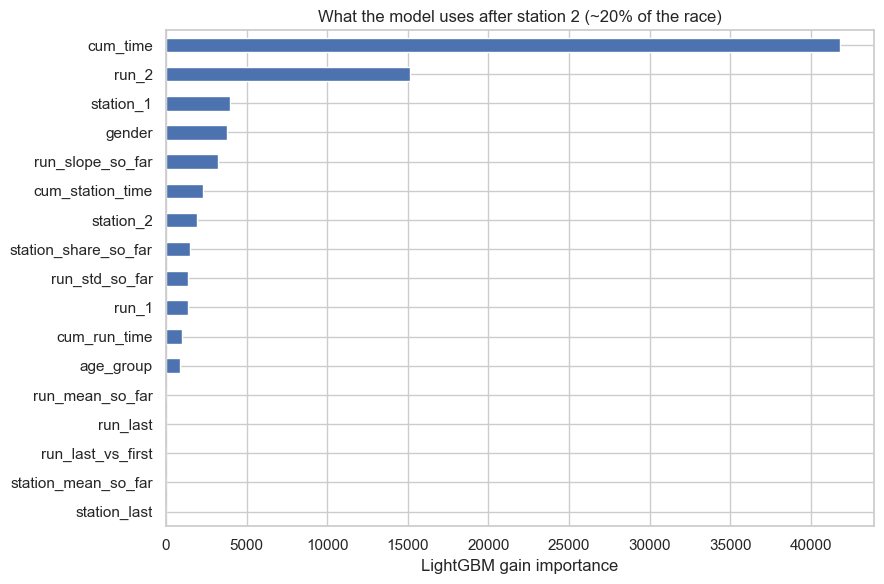

In [7]:
from lightgbm import LGBMRegressor
from src.models.inrace import DEFAULT_LGBM_PARAMS

K_DEMO = 4
X = build_checkpoint_features(df, K_DEMO)
y = df["overall_time"].astype(float)
m = LGBMRegressor(objective="quantile", alpha=0.5, random_state=42, **DEFAULT_LGBM_PARAMS).fit(X, y)

imp = (pd.Series(m.booster_.feature_importance(importance_type="gain"), index=X.columns)
       .sort_values())
fig, ax = plt.subplots(figsize=(9, 6))
imp.plot.barh(color="#4C72B0", ax=ax)
ax.set_xlabel("LightGBM gain importance")
ax.set_title(f"What the model uses {checkpoint_label(K_DEMO)} (~20% of the race)")
plt.tight_layout()

#### One athlete's race, as the model saw it

Putting it together for a single athlete (picked as the median finisher of the largest event,
predictions from the fold where that event was held out — so the model has never seen this
venue): the forecast starts wide, tracks the truth, and tightens to a few minutes by the closing
stations. This is the product the flagship model implies — a live finish-time forecast with
honest error bars.

S6 London 2023 - athlete finished in 87.9 min (event median 87.9)


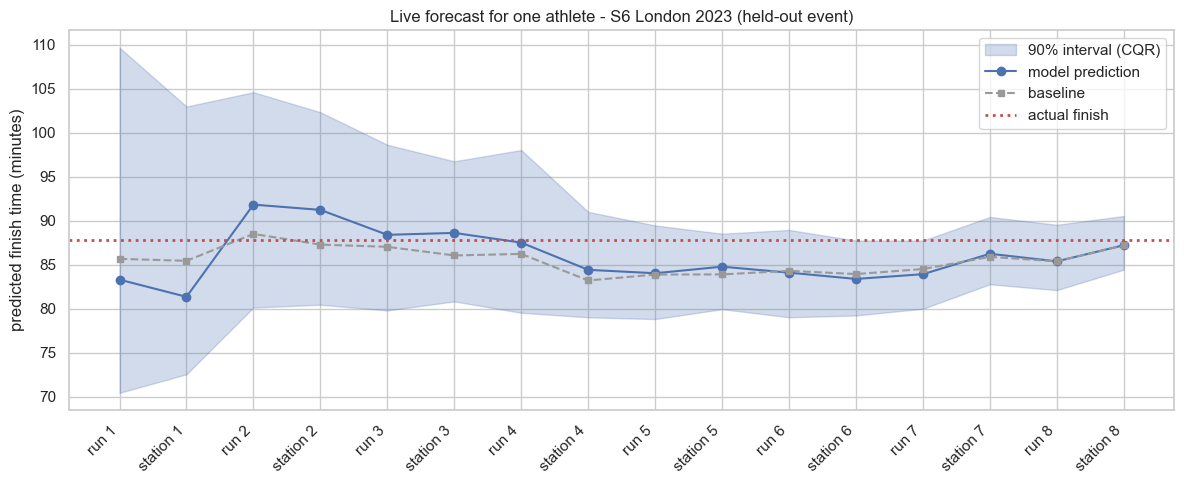

In [8]:
biggest = preds.event_id.value_counts().index[0]
ev = preds[(preds.event_id == biggest) & (preds.checkpoint == 16)]
target_row = ev.iloc[(ev.y_true - ev.y_true.median()).abs().argsort().iloc[0]].row
athlete = preds[(preds.row == target_row)].sort_values("checkpoint")
meta = df.loc[target_row]
print(f"{meta.event_name} - athlete finished in {meta.overall_time/60:.1f} min "
      f"(event median {ev.y_true.median()/60:.1f})")

fig, ax = plt.subplots(figsize=(12, 5))
x = athlete.checkpoint
ax.fill_between(x, athlete.q_lo_cqr / 60, athlete.q_hi_cqr / 60,
                alpha=0.25, color="#4C72B0", label="90% interval (CQR)")
ax.plot(x, athlete.model_pred / 60, "o-", color="#4C72B0", label="model prediction")
ax.plot(x, athlete.baseline_pred / 60, "s--", color="#999999", ms=4, label="baseline")
ax.axhline(athlete.y_true.iloc[0] / 60, color="#C44E52", ls=":", lw=2, label="actual finish")
ax.set_xticks(x)
ax.set_xticklabels([s.replace("_", " ") for s in athlete.segment], rotation=45, ha="right")
ax.set_ylabel("predicted finish time (minutes)")
ax.set_title(f"Live forecast for one athlete - {meta.event_name} (held-out event)")
ax.legend()
plt.tight_layout()

### Discussion

**What the result is.** A checkpoint-by-checkpoint finish-time forecaster that beats a
knowledgeable-spectator baseline at 15 of 16 checkpoints — by ~21% after the first run, where
forecasting is hardest and most useful — with 90% prediction intervals that *actually cover 90%*
of athletes at unseen events. The headline figure is the pair of curves: error falling from ~11
to ~1.5 minutes, interval width from ~43 to ~6, as the race reveals itself.

**What we'd flag in review:**

- **Conditional on finishing.** The results site lists finishers only (notebook 1), so every
  prediction is implicitly "…if you finish at your current pattern". A deployed mid-race
  forecaster would also need a DNF/blow-up risk component that this data cannot estimate.
- **The intervals are marginal, not per-athlete.** 90% coverage is across athletes, not a
  per-athlete guarantee; an athlete pacing erratically gets the same widening as a metronome.
  Conditional coverage (e.g. coverage within finish-time bands) is a natural follow-up.
- **The last-checkpoint loss is informative.** Once only transition time is unknown, a learned
  model has nothing to add over arithmetic — and modeling remaining-roxzone explicitly would
  likely close that 5% gap.
- **Event shift is the binding constraint.** Both headline phenomena — the baseline's stubborn
  early-race error and the raw intervals' undercoverage — trace to between-event differences the
  within-race features can't see. That is precisely the Phase 3 question: **how much of an
  event's offset is the venue itself?** If venue effects are identifiable, they become legal
  pre-race features for these models, and the early-race error should drop further.

**Next:** notebook 3 builds the venue difficulty model — hierarchical, with venue random
effects, and an explicit fight with the field-strength confounder flagged in notebook 1.